<a href="https://colab.research.google.com/github/reshmaamal09/AQI-Final-Project/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Real Time Air Quality Index (AQI)**

###**Objective**:

The main goal of this project is to analyze air pollution levels across different cities and states using AQI-related data.

###**The project focuses on:**


*  Understanding pollution distribution

*  Identifying highly polluted cities and states

*  Analyzing pollutant contribution

*  Finding relationships between pollutants



###**Why this is important**

Air pollution has serious health and environmental impacts. This analysis helps policymakers, researchers, and citizens understand where pollution is severe and which pollutants are responsible.

###**Tools & Libraries Used:**


Python

NumPy

Pandas

Matplotlib

Seaborn

###**Load the Dataset**

In [ ]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset
from google.colab import files
uploaded=files.upload()

Saving Real time Air Quality Index(AQI).csv to Real time Air Quality Index(AQI).csv


In [ ]:
df=pd.read_csv('Real time Air Quality Index(AQI).csv')
df.head(10)

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Bihar,Araria,"Kharahiya Basti, Araria - BSPCB",15-01-2026 12:00,26.146529,87.454184,PM10,31.0,155.0,90.0
1,India,Bihar,Arrah,"New DM Office, Arrah - BSPCB",15-01-2026 12:00,25.562610,84.663264,PM2.5,30.0,78.0,53.0
2,India,Bihar,Arrah,"New DM Office, Arrah - BSPCB",15-01-2026 12:00,25.562610,84.663264,PM10,44.0,110.0,78.0
3,India,Bihar,Arrah,"New DM Office, Arrah - BSPCB",15-01-2026 12:00,25.562610,84.663264,SO2,10.0,10.0,10.0
4,India,Bihar,Arrah,"New DM Office, Arrah - BSPCB",15-01-2026 12:00,25.562610,84.663264,CO,42.0,70.0,52.0
5,India,Bihar,Aurangabad,"Gurdeo Nagar, Aurangabad - BSPCB",15-01-2026 12:00,24.757460,84.366208,PM2.5,NaN,NaN,NaN
6,India,Bihar,Aurangabad,"Gurdeo Nagar, Aurangabad - BSPCB",15-01-2026 12:00,24.757460,84.366208,NO2,NaN,NaN,NaN
7,India,Bihar,Aurangabad,"Gurdeo Nagar, Aurangabad - BSPCB",15-01-2026 12:00,24.757460,84.366208,CO,101.0,103.0,102.0
8,India,Bihar,Begusarai,"Lohiyanagar, Begusarai - BSPCB",15-01-2026 12:00,25.427420,86.138861,PM2.5,57.0,305.0,102.0
9,India,Bihar,Begusarai,"Lohiyanagar, Begusarai - BSPCB",15-01-2026 12:00,25.427420,86.138861,NO2,10.0,16.0,13.0


| Column Name      | Description                                                        |
| ---------------- | ------------------------------------------------------------------ |
| Country      | Country Name             |
| State          | State Name                |
| City    | City Name |
| Station  | Monitoring station|
| last_update         | Date & time of reading|
| latitude     | Latitude of station|
| longitude  | Longitude of station |
| pollutant_id | Type of pollutant (PM2.5, PM10, CO, SO2, etc.)|
| pollutant_min              | Minimum pollutant value  |
| pollutant_max         | Maximum pollutant value       |
| pollutant_avg         | Average pollutant value       |


###**Understand the Dataset**

In [ ]:
# Dataset shape

print("Dataset shape:",df.shape)

Dataset shape: (3306, 11)


In [ ]:
# Dataset size

print("Dataset size:",df.size)

Dataset size: 36366


In [ ]:
# Dataset information

print("Dataset info:",df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        3306 non-null   object 
 1   state          3306 non-null   object 
 2   city           3306 non-null   object 
 3   station        3306 non-null   object 
 4   last_update    3306 non-null   object 
 5   latitude       3306 non-null   float64
 6   longitude      3306 non-null   float64
 7   pollutant_id   3306 non-null   object 
 8   pollutant_min  3102 non-null   float64
 9   pollutant_max  3102 non-null   float64
 10  pollutant_avg  3102 non-null   float64
dtypes: float64(5), object(6)
memory usage: 284.2+ KB
Dataset info: None


In [ ]:
# Statistical summary

print("Statistical summary:")
print(df.describe())

Statistical summary:
          latitude    longitude  pollutant_min  pollutant_max  pollutant_avg
count  3306.000000  3306.000000    3102.000000    3102.000000    3102.000000
mean     22.884283    78.601699      33.406834      94.368472      57.257576
std       5.398892     4.778608      43.741739     106.155229      68.207333
min       8.514909    70.909168       1.000000       1.000000       1.000000
25%      19.108610    75.644272       6.000000      18.000000      12.000000
50%      23.549395    77.315741      17.000000      58.000000      31.000000
75%      27.290523    80.612222      46.000000     122.000000      77.750000
max      34.066206    94.636574     334.000000     500.000000     387.000000


In [ ]:
# Column names

df.columns

Index(['country', 'state', 'city', 'station', 'last_update', 'latitude',
       'longitude', 'pollutant_id', 'pollutant_min', 'pollutant_max',
       'pollutant_avg'],
      dtype='object')

The dataset contain 3306 rows and 11 columns. Total records is 3,306. It contains mixture of numerical, categorical, datetime data and information regarding pollution metrics and location.



####**Key columns:**
Country name,
State  name
, Monitoring station,
Last update,
pollutant_id, pollutant_min, pollutant_max, pollutant_avg.

This step helps understand the size, structure, data types, and basic statistics of the dataset.


###**Date Cleaning and Preprocessing**

In [ ]:
# Examining datatypes

df.dtypes

,0
country,object
state,object
city,object
station,object
last_update,object
latitude,float64
longitude,float64
pollutant_id,object
pollutant_min,float64
pollutant_max,float64


In [ ]:
# Converting data type of column 'last_update'

df['last_update']=pd.to_datetime(df['last_update'])

/tmp/ipython-input-2382585136.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['last_update']=pd.to_datetime(df['last_update'])


In [ ]:
# Checking missing values

df.isnull().sum()

,0
country,0
state,0
city,0
station,0
last_update,0
latitude,0
longitude,0
pollutant_id,0
pollutant_min,204
pollutant_max,204


In [ ]:
# Imputing missing values with mean

df['pollutant_min']=df['pollutant_min'].fillna(df['pollutant_min'].mean())
df['pollutant_max']=df['pollutant_max'].fillna(df['pollutant_max'].mean())
df['pollutant_avg']=df['pollutant_avg'].fillna(df['pollutant_avg'].mean())

In [ ]:
df.isnull().sum()

,0
country,0
state,0
city,0
station,0
last_update,0
latitude,0
longitude,0
pollutant_id,0
pollutant_min,0
pollutant_max,0


In [ ]:
# Checking unique values

df.nunique()

,0
country,1
state,29
city,257
station,497
last_update,1
latitude,497
longitude,497
pollutant_id,7
pollutant_min,208
pollutant_max,399


In [ ]:
# Check duplicates

df.duplicated().sum()

np.int64(0)

In [ ]:
# Extracting year

df['year']=df['last_update'].dt.year

In [ ]:
# Calculate the average of pollutant_avg

avg_pollution = df['pollutant_avg'].mean()


In [ ]:
# Create an empty list to store aqi_category values and used a for loop to classify pollution levels

avg_list=[]
for i in df['pollutant_avg']:
    if i > avg_pollution:
        avg_list.append('Above Average')
    elif i < avg_pollution:
        avg_list.append('Below Average')
    else:
        avg_list.append('Average')

In [ ]:
# Add the list as a new column
df['aqi_category']=avg_list

In [ ]:
# Check the result

df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg,year,aqi_category
0,India,Bihar,Araria,"Kharahiya Basti, Araria - BSPCB",2026-01-15 12:00:00,26.146529,87.454184,PM10,31.0,155.0,90.0,2026,Above Average
1,India,Bihar,Arrah,"New DM Office, Arrah - BSPCB",2026-01-15 12:00:00,25.562610,84.663264,PM2.5,30.0,78.0,53.0,2026,Below Average
2,India,Bihar,Arrah,"New DM Office, Arrah - BSPCB",2026-01-15 12:00:00,25.562610,84.663264,PM10,44.0,110.0,78.0,2026,Above Average
3,India,Bihar,Arrah,"New DM Office, Arrah - BSPCB",2026-01-15 12:00:00,25.562610,84.663264,SO2,10.0,10.0,10.0,2026,Below Average
4,India,Bihar,Arrah,"New DM Office, Arrah - BSPCB",2026-01-15 12:00:00,25.562610,84.663264,CO,42.0,70.0,52.0,2026,Below Average





*   Columns with incorrect or inconsistent data types were identified and converted to appropriate formats such as numeric and datetime to ensure accurate analysis.

*   The mean of the polutant_avg column was calculated. Using a for loop, each pollutant value was compared against the mean and categorized as Above Average, Average, or Below Average. The resulting labels were stored in a new column named avg_level.




##**Exploratory Data Analysis (EDA)**

##**Univariate analysis**

####**1. Plot a histogram showing the distribution of average pollution**

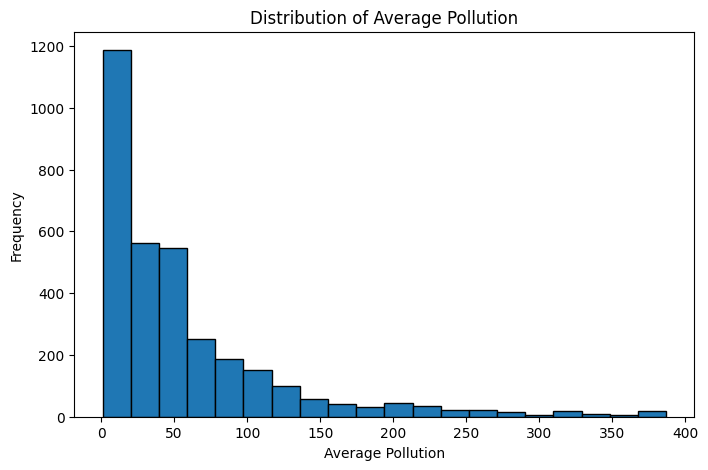

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['pollutant_avg'], bins=20, edgecolor='black')
plt.xlabel('Average Pollution')
plt.ylabel('Frequency')
plt.title('Distribution of Average Pollution')
plt.show()

####**Insights:**  

*   The distribution of average pollution values is right-skewed.

*   Most observations fall in the 0–50 pollution range, indicating low to moderate pollution levels.

*   Frequency of observations decreases as pollution levels increase.

*   Very few locations record average pollution values above 150.

*   The long right tail (values above 300) indicates extreme pollution events.

*   These extreme values suggest the presence of localized pollution hotspots.

*   High variability in pollution levels highlights uneven air quality across locations.







####**2. Pollution Category Count**

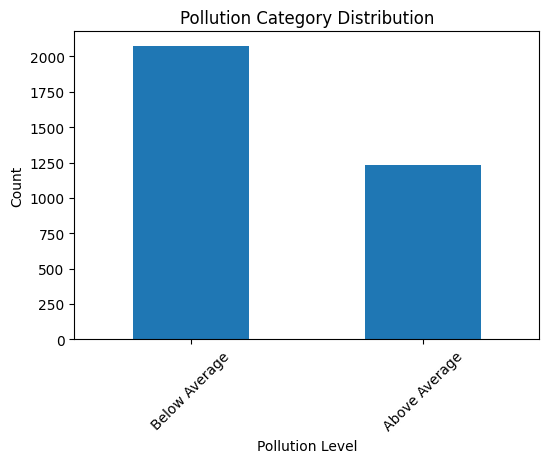

In [ ]:
plt.figure(figsize=(6,4))
df['aqi_category'].value_counts().plot(kind='bar')
plt.xlabel('Pollution Level')
plt.ylabel('Count')
plt.title('Pollution Category Distribution')
plt.xticks(rotation=45)
plt.show()


####**Insights:**

*   The “Below Average” pollution category has the highest count, indicating that most monitoring stations record pollution levels below the overall average.

*   A significant number of observations still fall under the “Above Average” category, showing that elevated pollution levels are common in several locations.

*   The distribution is imbalanced, with below-average pollution occurring more frequently than above-average pollution.
*   Despite the dominance of below-average values, the presence of many above-average readings suggests localized pollution hotspots.


*   This pattern indicates that air quality is generally moderate, but certain regions experience consistently higher pollution levels.


*   The chart highlights the need for targeted pollution control measures in areas classified as above average.



##**Bivariate Analysis**

####**3. Show the top 10 most pollutedcCities**

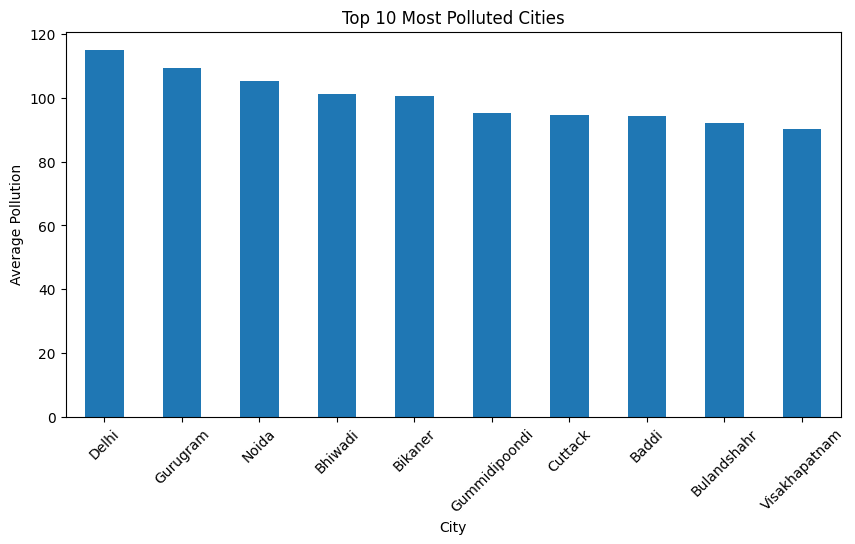

In [ ]:
top_cities = df.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_cities.plot(kind='bar')
plt.xlabel('City')
plt.ylabel('Average Pollution')
plt.title('Top 10 Most Polluted Cities')
plt.xticks(rotation=45)
plt.show()


####**Insights:**

*   Delhi records the highest average pollution level, making it the most polluted city in the dataset.

*   Gurugram and Noida closely follow Delhi, indicating severe pollution in the NCR region.

*   Multiple cities from North India dominate the top 10 list, suggesting regional pollution concentration.

*   Cities like Bhiwadi and Bikaner show high pollution levels despite smaller city sizes, indicating industrial or localized emission sources.

*   Gummidipoondi appears among the top polluted cities, highlighting the impact of industrial zones on air quality.

*   Cuttack and Baddi exhibit similar pollution levels, reflecting moderate to high pollution conditions.

*   Visakhapatnam, though a coastal city, still shows high average pollution, suggesting industrial and port-related emissions.

*   The overall pollution levels among the top 10 cities are consistently high, with relatively small variation, indicating persistent pollution rather than occasional spikes.

####**4. What is the state_wise average pollution**

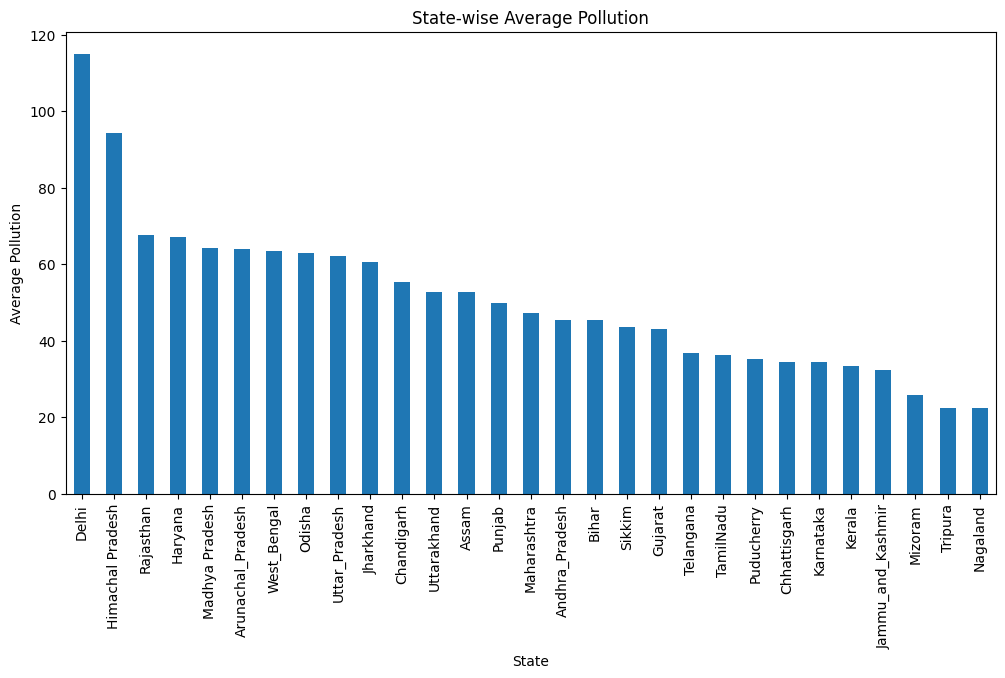

In [ ]:
state_pollution = df.groupby('state')['pollutant_avg'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
state_pollution.plot(kind='bar')
plt.xlabel('State')
plt.ylabel('Average Pollution')
plt.title('State-wise Average Pollution')
plt.show()


####**Insights:**

*   Delhi records the highest average pollution level, standing out significantly compared to other states and union territories.

*   Himachal Pradesh ranks second, indicating that even hilly regions can experience elevated pollution levels, possibly due to seasonal factors or local activities.

*   Rajasthan and Haryana show relatively high pollution levels, reflecting the impact of dust, industrial activity, and urbanization.

*   Several populous states such as Uttar Pradesh, West Bengal, and Odisha exhibit moderate to high average pollution, indicating widespread air quality challenges.

*   Northern and central states dominate the higher pollution range, suggesting regional clustering of air pollution.

*   States like Punjab, Maharashtra, and Andhra Pradesh fall in the mid-range, indicating comparatively moderate pollution levels.

*   Southern and northeastern states, including Tamil Nadu, Kerala, Mizoram, Tripura, and Nagaland, record lower average pollution levels.

*   Nagaland and Tripura show the lowest average pollution, indicating relatively cleaner air quality in these regions.

* The wide variation across states highlights uneven air quality distribution across India.

####**5. Relationship Between Two Pollutants**

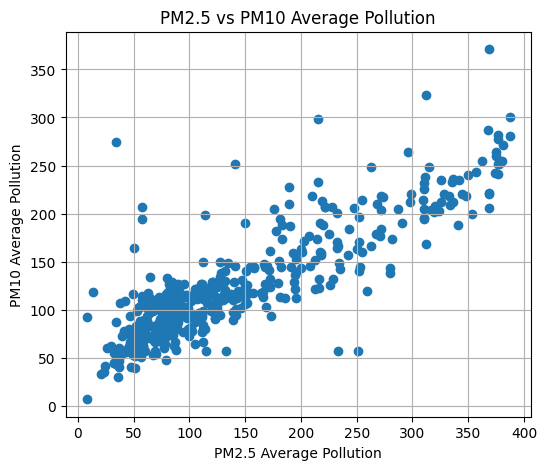

In [ ]:
pivoted_df = df.pivot_table(index=['state', 'city', 'station', 'latitude', 'longitude', 'last_update'],
                            columns='pollutant_id',
                            values='pollutant_avg').reset_index()

if 'PM2.5' in pivoted_df.columns and 'PM10' in pivoted_df.columns:
    pivoted_df_cleaned = pivoted_df.dropna(subset=['PM2.5', 'PM10'])

    plt.figure(figsize=(6,5))
    plt.scatter(pivoted_df_cleaned['PM2.5'], pivoted_df_cleaned['PM10'])
    plt.xlabel('PM2.5 Average Pollution')
    plt.ylabel('PM10 Average Pollution')
    plt.title('PM2.5 vs PM10 Average Pollution')
    plt.grid(True)
    plt.show()
else:
    print("One or both of 'PM2.5' or 'PM10' not found in the dataset after pivoting. Please check the 'pollutant_id' values.")

####**Insights:**

*   The scatter plot shows a strong positive correlation between PM2.5 and PM10 pollution levels.

*   As PM2.5 concentrations increase, PM10 levels also tend to increase, indicating a close relationship between the two pollutants.

*   Most data points are clustered in the low to moderate pollution range, suggesting common pollution levels across many locations.
*   Several points appear in the high pollution range, reflecting severe particulate pollution episodes.


*   The linear upward trend indicates that both pollutants often originate from similar sources, such as vehicular emissions, construction activities, and industrial processes.

*   A few scattered outliers suggest localized factors or short-term pollution spikes.

*   The strong association implies that reducing PM2.5 emissions may also help lower PM10 levels.




####**6. Show the pollutant wise pollution distribution**

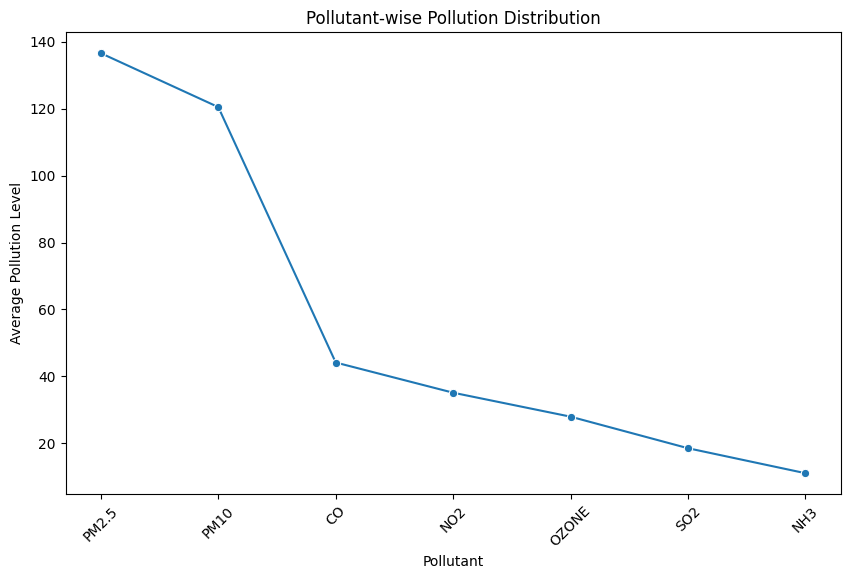

In [ ]:
avg_pollutant_distribution = df.groupby('pollutant_id')['pollutant_avg'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.lineplot(x=avg_pollutant_distribution.index, y=avg_pollutant_distribution.values, marker='o')
plt.title('Pollutant-wise Pollution Distribution')
plt.xlabel('Pollutant')
plt.ylabel('Average Pollution Level')
plt.xticks(rotation=45)
plt.show()

####**Insights:**

*   PM2.5 has the highest average pollution level, making it the most dominant pollutant in the dataset.

*   PM10 is the second highest contributor, closely following PM2.5, indicating a high presence of particulate matter.


*  The sharp drop from PM10 to CO shows that gaseous pollutants are significantly lower than particulate pollutants.

*   CO and NO₂ show moderate pollution levels, suggesting regular exposure from traffic and combustion sources.
*  Ozone (O₃) levels are lower than CO and NO₂, indicating relatively controlled secondary pollutant formation.
*  SO₂ pollution is minimal, implying limited influence from coal-based industries or effective emission controls.
*   NH₃ has the lowest average concentration, suggesting minimal agricultural or waste-related emissions in the observed data.

*   Overall, particulate matter (PM2.5 and PM10) is the major contributor to air pollution compared to gaseous pollutants.






####**7. How pollution spread over cities**

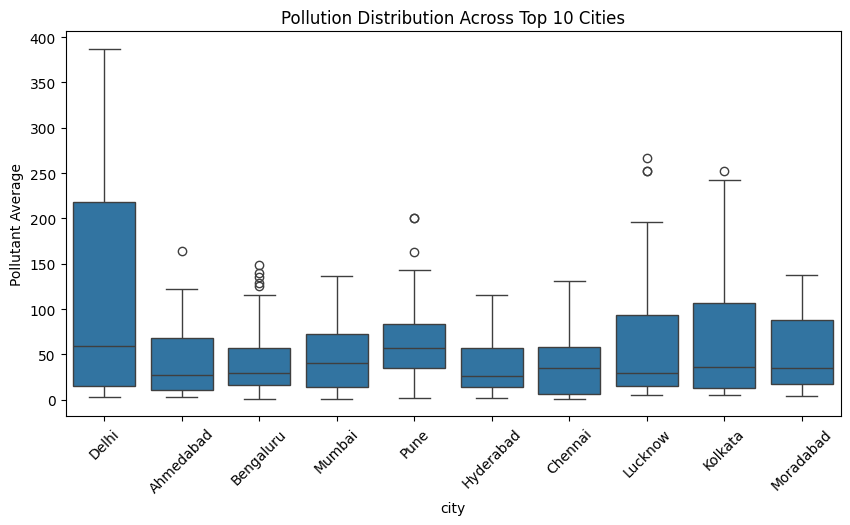

In [ ]:
top10_cities = df['city'].value_counts().head(10).index
city_data = df[df['city'].isin(top10_cities)]

plt.figure(figsize=(10,5))
sns.boxplot(x='city', y='pollutant_avg', data=city_data)
plt.xticks(rotation=45)
plt.title("Pollution Distribution Across Top 10 Cities")
plt.ylabel("Pollutant Average")
plt.show()


####**Insights:**

*   Delhi shows the highest pollution variability, with a very wide range and extreme upper values, indicating frequent severe pollution episodes.

*   The median pollution level in Delhi is higher than most other cities, suggesting consistently poor air quality.

*   Kolkata and Lucknow also record high upper ranges, highlighting periodic spikes in pollution levels.

*   Pune and Mumbai exhibit moderate pollution levels, with relatively balanced distributions and fewer extreme outliers.

*   Ahmedabad and Bengaluru show lower median pollution values, indicating comparatively better air quality.

*   Hyderabad and Chennai have narrower box ranges, suggesting more stable and less fluctuating pollution levels.


*   Outliers in multiple cities indicate occasional abnormal pollution events, possibly due to festivals, traffic congestion, or weather conditions.

*   Cities with wider boxes and longer whiskers reflect greater pollution inconsistency, while compact boxes indicate more uniform air quality.

*   Overall, northern cities tend to experience higher and more volatile pollution compared to southern cities.



##**Multivariate analysis**

####**8. What is the relationship between pollutant max, min, and average**

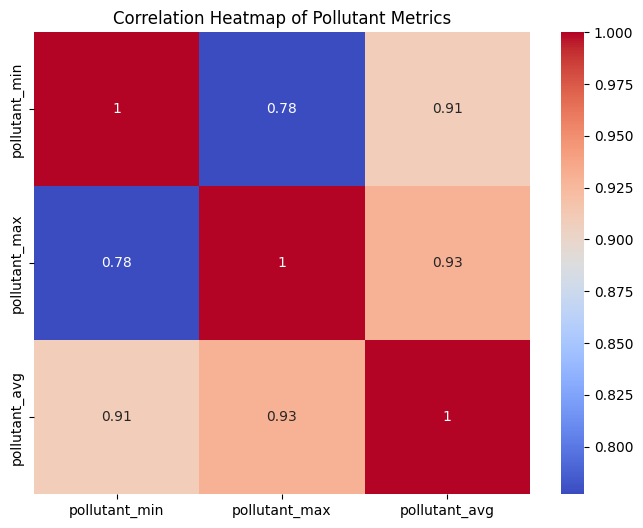

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['pollutant_min','pollutant_max','pollutant_avg']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Pollutant Metrics')
plt.show()

####**Insights:**


#####**1.   Strong positive correlation between average and maximum pollution**


*   pollutant_avg and pollutant_max show a very high correlation (~0.93).

*   This indicates that areas with higher peak pollution levels also tend to have higher average pollution.




#####**2.   Average pollution is closely linked with minimum pollution levels**

*   pollutant_avg has a strong correlation (~0.91) with pollutant_min.

*   This suggests that consistently high baseline pollution significantly influences the overall average.




#####**3.  Minimum and maximum pollution are moderately to strongly correlated**

*   The correlation between pollutant_min and pollutant_max is ~0.78.

*   This implies that locations with higher minimum pollution often experience higher pollution peaks, but with some variability.



#####**4.  High multicollinearity among pollution metrics**

*   All three variables (min, max, avg) are strongly correlated (>0.75).

*   This indicates that these features capture overlapping information.





#####**5.   Implication for modeling and feature selection**

*   Due to strong correlations, using all three metrics together in machine learning models may introduce multicollinearity.

*   pollutant_avg alone could serve as a representative feature for overall pollution levels.

#####**6.   Environmental interpretation**


*   Pollution levels appear to be persistent rather than sporadic, meaning areas with high pollution tend to remain polluted across minimum, average, and maximum measures.

####**9. Show the pollutant contribution using pie chart**

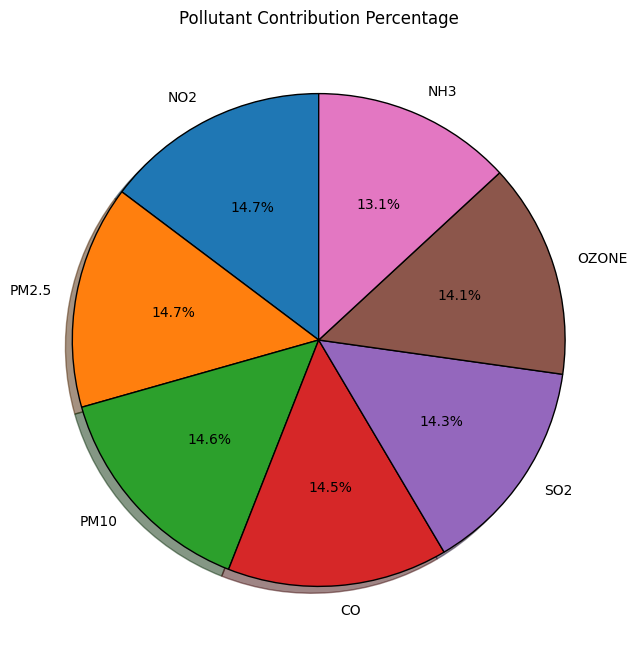

In [ ]:
pollutant_counts = df['pollutant_id'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(pollutant_counts, labels=pollutant_counts.index, autopct='%1.1f%%',shadow=True, startangle=90, wedgeprops=dict(edgecolor='black'))
plt.title('Pollutant Contribution Percentage')
plt.show()

####**Insights:**

#####**1.Pollution contribution is almost evenly distributed**   

  
*   All pollutants contribute roughly 13%–15% each.

* No single pollutant overwhelmingly dominates overall pollution levels.



#####**2.PM2.5 and NO₂ are the joint highest contributors**   

*  Both PM2.5 and NO₂ contribute ~14.7%, making them the largest individual contributors.

*   These pollutants are commonly linked to vehicular and industrial emissions.

#####**3.PM10 and CO also play a significant role**   

*   PM10 contributes ~14.6%, while CO contributes ~14.5%.

*   This indicates strong influence from road dust, combustion, and traffic sources.

#####**4.SO₂ and Ozone have moderate but comparable impact**   

*   SO₂ (~14.3%) and Ozone (~14.1%) show similar contribution levels.

*   Their presence suggests industrial activity and secondary atmospheric reactions.

#####**5.NH₃ is the lowest contributor, but still notable**

*  NH₃ contributes ~13.1%, the smallest share among pollutants.

*   Despite being lowest, its contribution is still substantial and cannot be ignored.

#####**6.Implication for pollution control strategies**  

*  Since contributions are evenly spread, multi-pollutant control strategies are required.

*   Focusing on just one pollutant would have limited overall impact.




#**Insight Generation & Final Report**







###**1. Objective of the Analysis**

The objective of this analysis is to examine air quality patterns using Air Quality Index (AQI) data. The study aims to analyze pollution levels across cities and states, understand the distribution and contribution of different pollutants, and explore relationships among pollutants through exploratory data analysis. The insights obtained from this analysis help in identifying pollution hotspots and support data-driven environmental decision-making.

###**2. Data Preparation Summary**

The dataset was prepared through a structured data preprocessing process to ensure accuracy and consistency. The following steps were carried out:

*   Loaded the dataset using Python (Pandas).

*   Inspected dataset structure, dimensions, and data types.

*   Converted incorrect data types into appropriate numerical and datetime formats.

*   Checked and handled missing values to maintain data integrity.

*   Removed duplicate records to prevent biased results.

*   Created a new feature representing the average pollution level across all pollutants.

*   Categorized pollution levels into Below Average, Average, and Above Average categories.

*   After these steps, the dataset was clean, reliable, and ready for exploratory data analysis.


###**3. Exploratory Data Analysis (EDA) Overview**

Exploratory Data Analysis was conducted to identify patterns, trends, and relationships in the data. The EDA process was divided into the following categories:

*   Univariate Analysis: Examined individual variables such as pollutant concentrations and average pollution levels using histograms and boxplots.

*   Bivariate Analysis: Analyzed relationships between pollution levels and geographical factors such as cities and states using bar charts and scatter plots.

*   Multivariate Analysis: Explored correlations among multiple pollutants using heatmaps and comparative visualizations.

*   Various visual tools such as histograms, boxplots, bar charts, scatter plots, heatmaps, and pie charts were used to extract meaningful insights.

###**4. Key Analytical Insights from Visual Exploration**

#####**1.    Majority of Regions Experience Above-Average Pollution**

Histogram and category distribution charts show that most observations fall under the Above Average pollution category, indicating that poor air quality is a widespread issue rather than isolated to a few regions.

#####**2.   Pollution Is Concentrated in Specific Cities**

Bar charts of city-wise pollution levels reveal that a small number of cities contribute disproportionately to overall pollution. These cities act as pollution hotspots and require focused regulatory intervention.

#####**3.   Certain States Consistently Show Higher Pollution Levels**

State-wise aggregation highlights that industrialized and densely populated states consistently record higher average pollution levels, suggesting a strong link between economic activity, population density, and air pollution.

#####**4.    A Few Pollutants Dominate Overall Pollution**

Pie chart and boxplot analysis indicate that only a small number of pollutants contribute significantly to the total pollution load. Controlling these dominant pollutants can lead to substantial improvements in air quality.

#####**5.    Strong Correlation Exists Between Certain Pollutants**

Correlation heatmaps and scatter plots reveal strong positive relationships between specific pollutants, suggesting common emission sources such as vehicular traffic and industrial processes.


#**Overall Findings and Conclusion**

The analysis demonstrates that air pollution is a persistent and serious environmental challenge. Pollution levels are generally above average across most regions, with certain cities and states emerging as major pollution hotspots. A limited number of pollutants dominate the pollution profile, and strong correlations among pollutants indicate shared sources of emissions. These findings emphasize the need for targeted and data-driven air quality management strategies.

#**Recommendations**

Based on the insights derived from this analysis, the following recommendations are proposed:

*   **Target Pollution Hotspots:**
Focus air quality control measures on cities and states identified as major contributors to pollution.

*   **Control Dominant Pollutants:**
Regulatory efforts should prioritize pollutants that contribute most significantly to overall pollution.

*   **Strengthen Emission Regulations:**
Enforce stricter industrial and vehicular emission standards to reduce pollution at the source.

*   **Promote Sustainable Transportation:**
Encourage the use of public transport, electric vehicles, and non-polluting mobility options.

*   **Enhance Monitoring and Awareness:**
Expand real-time air quality monitoring systems and increase public awareness about pollution impacts and preventive measures.



#Project Completed